<a href="https://colab.research.google.com/github/brandonviaje/NLP-Case-Study/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSCI 4050U - Final Project

Group ID: 49

Brandon Viaje 100912514

Ethan Warriner

# Overview

## Case Study: NLP Architectures for Sentiment Analysis

<img src="https://www.displayr.com/wp-content/uploads/2024/10/3-tips-sentiment-analysis-1024x625.png" width="500" height="auto">

Sentiment Analysis is the task of identifying the sentiment (positive, negative, or neutral) in text data.  

It has applications in:  
- Customer feedback analysis  
- Social media monitoring  
- Product reviews  

This case study compares different NLP architectures for sentiment analysis in terms of performance and complexity.


## Data Description

**Dataset Used:** [IMDB Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)  

- Number of samples: 50,000 reviews  
- Classes: Positive / Negative  
- Preprocessing steps:
  1. Data Loading
  2. Data Cleaning
  3. Tokenization
  4. Build Vocabulary
  5. Integer Encoding

High-Level:

Text → Tokens → Integers → Tensors


## Models

We will examine four main architectures:

*   **RNNs** (Recurrent Neural Networks)
*   **LSTM** (Long Short-Term Memory)
*   **GRU** (Gated Recurrent Units)
*   **Transformers** (e.g., DistilBERT)



# Data Loading


In [ ]:
! pip install lightning > /dev/null
! pip install transformers > /dev/null
! pip install contractions > /dev/null

In [ ]:
# Standard Library
import os
import re
import shutil
import time
import warnings
from collections import Counter

# Third-Party Libraries
import contractions
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import torch
import torch.nn as nn
from datasets import load_dataset, concatenate_datasets
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer

# PyTorch Utilities
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset, random_split

# PyTorch Lightning
from lightning import LightningDataModule, seed_everything
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch import LightningModule

# TorchMetrics
from torchmetrics.classification import BinaryAccuracy

# Google Colab
from google.colab import drive

# Warning Filters
warnings.filterwarnings("ignore")

In [ ]:
# Mount Drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset Analysis

We will be analyzing our IMDB movie review dataset for extra clarity.

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/CSCI4050U/IMDB-Dataset.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Content
Our dataset consists of 50,000 rows with two columns:

1. Review
2. Sentiment



In [ ]:
df.shape

(50000, 2)

## Dataset Balanced

As observed from below, we have a very balanced dataset.

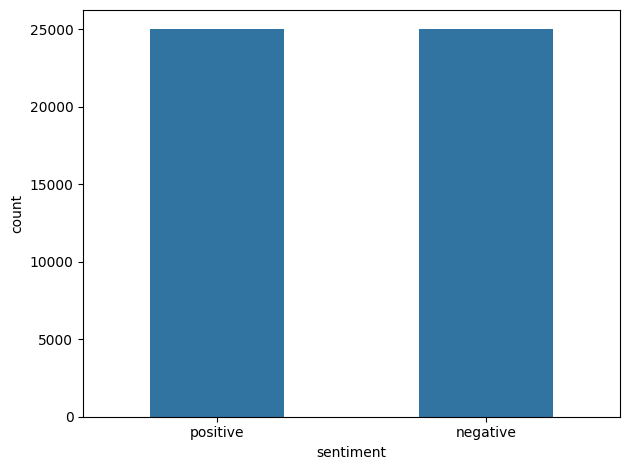

In [ ]:
ax = sns.countplot(x='sentiment', data=df, width=0.5)
ax.tick_params(axis='x', rotation=360)
plt.tight_layout()
plt.show()

# Data Preprocessing

We create a class that contains all the necessary functions needed to preprocess our IMDB dataset.

In [ ]:
important_words =  {"not", "no", "never", "none", "can't", "won't", "don't", "didn't", "nothing", "nowhere"}

In [ ]:
class IMDBPreProcessor():
  def __init__(self, important_words):
    self.nlp = spacy.load("en_core_web_sm", exclude=['ner','textcat','parser'])                     # load spacy NLP model and disable unneeded components
    self.important_words = important_words                                                          # set important_words
    self.vocab = None                                                                               # set vocab to None

  def clean_text(self, text):
    text = contractions.fix(text)                                                                   # expand contractions
    text = text.lower().strip()                                                                     # set to lower case and remove leading/trailing whitespace
    text = re.findall(r"[A-Za-z]{3,50}", text)                                                      # return list of alpha characters from length 3 to 50
    return " ".join(text)

  def clean_df(self,df):
    df['review'] = df['review'].astype(str).apply(self.clean_text)                                  # apply text cleaning to all review rows
    return df

  def filter_doc(self,doc):
    tokens = []
    for token in doc:
        if not token.is_alpha:                                                                      # skip non-alpha tokens
            continue
        if token.is_stop and token.text not in self.important_words:                                # skip stop words that are not important
            continue
        tokens.append(token.lemma_)                                                                 # only add alpha lemmatized tokens that isn't a stop word
    return tokens

  def tokenize_df(self,df):
    texts = df['review']                                                                            # gets column of cleaned text
    docs = self.nlp.pipe(texts, batch_size=100, n_process=-1)                                       # process texts in batches using spacy pipeline, tokenizes raw text
    token_lists = [self.filter_doc(doc) for doc in tqdm(docs, total=len(df), desc="Tokenizing")]    # iterate through docs and filter each doc. each doc corresponds to one review
    df['review'] = token_lists                                                                      # update review column with tokenized list

  def build_vocab(self,df):
    if self.vocab is not None:                                                                      # check if vocab is already built
        return self.vocab
    all_tokens = [token for tokens in df['review'] for token in tokens]                             # flatten token list into one list
    token_counts = Counter(all_tokens)                                                              # map frequency for tokens
    common_tokens = [token for token, _ in token_counts.most_common(10000)]                         # use the 10,000 most common tokens

    self.vocab = {"[PAD]" : 0, "[UNK]" : 1}                                                         # add pad and unknown token to vocab                                                                   # add unkown token to vocab
    self.vocab.update({token : i+2 for i, token in enumerate(common_tokens)})                       # add common tokens to lower IDs first, rarer tokens later

    return self.vocab

  def encode_tokens(self, tokens):
    if self.vocab is None:                                                                          # check if vocab is built
        raise ValueError("Vocab not built. Call build_vocab() first.")
    return [self.vocab.get(token, self.vocab["[UNK]"]) for token in tokens]                         # return encoded tokens

# Work Space

In [ ]:
# Load Dataset
df = pd.read_csv("/content/drive/MyDrive/CSCI4050U/IMDB-Dataset.csv")

# Split up Dataset: 70% train, 15% validation, 15% test
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)


In [ ]:
preprocess = IMDBPreProcessor(important_words)

# Train Set
train_df = preprocess.clean_df(train_df)
preprocess.tokenize_df(train_df)
vocab = preprocess.build_vocab(train_df)
train_df['encoded'] = train_df['review'].apply(preprocess.encode_tokens)

# Validation Set
val_df = preprocess.clean_df(val_df)
preprocess.tokenize_df(val_df)
val_df['encoded'] = val_df['review'].apply(preprocess.encode_tokens)

# Test Set
test_df = preprocess.clean_df(test_df)
preprocess.tokenize_df(test_df)
test_df['encoded'] = test_df['review'].apply(preprocess.encode_tokens)

Tokenizing: 100%|██████████| 7500/7500 [01:46<00:00, 70.65it/s]


In [ ]:
# train_df.to_pickle('train_df.pkl')
# val_df.to_pickle('val_df.pkl')
# test_df.to_pickle('test_df.pkl')

For times sake, we have already ran the preprocessing pipeline and saved it in a pickle. We will be using our preprocessed uploaded pickled dataframes.

In [ ]:
train_df = pd.read_pickle('/content/drive/MyDrive/CSCI4050U/train_df.pkl')
val_df = pd.read_pickle('/content/drive/MyDrive/CSCI4050U/val_df.pkl')
test_df = pd.read_pickle('/content/drive/MyDrive/CSCI4050U/test_df.pkl')

We create a class that converts our preprocessed dataframe into a dataset object used for training. In addition our collate_fn() deals with padding of each batch ensuring we have a consistent fixed size for our embedding layer.

In [ ]:
class IMDBDataset(Dataset):
  def __init__(self, df, transform=None, target_transform=None):
      self.df = df.copy()
      self.df['target'] = self.df['sentiment'].apply(self.encode_labels)
      self.transform = transform
      self.target_transform = target_transform

  def __len__(self):
      return len(self.df)

  def encode_labels(self,label):
    return 1 if label == 'positive' else 0

  def __getitem__(self, idx):
    return torch.tensor(self.df.iloc[idx]['encoded'], dtype=torch.long), torch.tensor(self.df.iloc[idx]['target'], dtype=torch.long)

In [ ]:
def collate_fn(batch):
    sequences, targets = zip(*batch)                                                         # unzip batch into sequences and targets
    sequences = pad_sequence(sequences, batch_first=True, padding_value=vocab["[PAD]"])      # pad with our pad token value
    targets = torch.stack(targets)                                                           # convert labels to tensor
    return sequences, targets

In [ ]:
# Convert dataframe to dataset object to prepare for training
train_dataset = IMDBDataset(train_df)
val_dataset = IMDBDataset(val_df)
test_dataset = IMDBDataset(test_df)

In [ ]:
# Create dataloader for our datasets
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

# Lightning Module

In [ ]:
class MyLightning(LightningModule):
  def __init__(self):
    super().__init__()
    self.accuracy = BinaryAccuracy()

  def configure_optimizers(self):
    return torch.optim.Adam(self.parameters(), lr=0.001)

  def loss(self, logits, target):
    return nn.CrossEntropyLoss()(logits, target)

  def shared_step(self, mode, batch):
    x, target = batch
    y = self.forward(x)
    loss = self.loss(y, target)
    self.accuracy(torch.argmax(y, dim=1), target)
    self.log(f"{mode}_step_acc", self.accuracy, prog_bar=True)
    self.log(f"{mode}_step_loss", loss, prog_bar=False)
    return loss

  def training_step(self, batch):
    return self.shared_step("train", batch)

  def validation_step(self, batch):
    return self.shared_step("val", batch)

  def test_step(self, batch):
    return self.shared_step("test", batch)

# Training Utility

In [ ]:
def train(*, name:str, model:LightningModule, epochs:int, train_loader:DataLoader, val_loader:DataLoader, test_loader:DataLoader):
  seed_everything(0)
  logger = CSVLogger(save_dir="logs/", name=name)
  trainer = Trainer(
      max_epochs=epochs,
      logger=logger
  )

  try:
    shutil.rmtree(f"./logs/{name}/")
    os.mkdirs(f"./logs/{name}")
  except:
    pass

  start = time.time()
  trainer.fit(model, train_loader, val_loader)
  duration = time.time() - start
  print(f"Training time: {duration:0.2f} seconds.")
  print(trainer.validate(model, val_loader))
  print(trainer.test(model, test_loader))

In [ ]:
vocab_size = len(vocab)
num_classes = 2

# RNN

In [ ]:
class MyRNN(MyLightning):
  def __init__(self, input_size, hidden_size):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, input_size)
    self.rnn = nn.RNN(input_size, hidden_size, num_layers=1, batch_first=True)
    self.fc = nn.Linear(hidden_size, num_classes)

  def forward(self, batch):
    embeddings = self.embedding(batch)
    out, _ = self.rnn(embeddings)
    out = self.fc(out[:, -1, :])
    return out

In [ ]:
train(name="rnn",
      model=MyRNN(16, 32),
      epochs=10,
      train_loader=train_loader,
      val_loader=val_loader,
      test_loader=test_loader)

# LSTM

In [ ]:
class MyLSTM(MyLightning):
  def __init__(self, input_size, hidden_size):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, input_size)
    self.lstm = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True)
    self.fc = nn.Linear(hidden_size, num_classes)

  def forward(self, batch):
    embeddings = self.embedding(batch)
    out, _ = self.lstm(embeddings)
    out = self.fc(out[:, -1, :])
    return out

In [ ]:
train(name="lstm",
      model=MyLSTM(16, 32),
      epochs=10,
      train_loader=train_loader,
      val_loader=val_loader,
      test_loader=test_loader)

INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name      | Type           | Params | Mode 
--------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[{'val_step_acc': 0.49453333020210266, 'val_step_loss': 0.6944069862365723}]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_step_acc       │    0.5001333355903625     │
│      test_step_loss       │    0.6947177052497864     │
└───────────────────────────┴───────────────────────────┘

[{'test_step_acc': 0.5001333355903625, 'test_step_loss': 0.6947177052497864}]


# GRU

In [ ]:
class MyGRU(MyLightning):
  def __init__(self, input_size, hidden_size):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, input_size)
    self.gru = nn.GRU(input_size, hidden_size, num_layers=1, batch_first=True)
    self.fc = nn.Linear(hidden_size, num_classes)

  def forward(self, batch):
    embeddings = self.embedding(batch)
    out, _ = self.gru(embeddings)
    out = self.fc(out[:, -1, :])
    return out

In [ ]:
train(name="gru",
      model=MyGRU(16, 32),
      epochs=10,
      train_loader=train_loader,
      val_loader=val_loader,
      test_loader=test_loader)

INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name      | Type           | Params | Mode 
--------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[{'val_step_acc': 0.8725333213806152, 'val_step_loss': 0.31431302428245544}]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_step_acc       │    0.8744000196456909     │
│      test_step_loss       │    0.3166990876197815     │
└───────────────────────────┴───────────────────────────┘

[{'test_step_acc': 0.8744000196456909, 'test_step_loss': 0.3166990876197815}]


# DistilBERT

In [ ]:
class MyDistilBERT(LightningModule):
  def __init__(self):
    super().__init__()
    self.model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased-finetuned-sst-2-english").train()

  """
  Feeds a batch into the model and:
  - Runs a forward pass
  - Computes the logits
  - Computes the loss
  """
  def get_output(self, batch):
    return self.model(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"],
        labels=batch["label"]
    )

  def training_step(self, batch):
    output = self.get_output(batch)
    self.log("train_loss", output.loss)
    return output.loss

  def validation_step(self, batch):
    output = self.get_output(batch)
    self.log("validation_loss", output.loss)
    return output.loss

  def test_step(self, batch):
    output = self.get_output(batch)
    self.log("test_loss", output.loss)
    return output.loss

  def configure_optimizers(self):
    return torch.optim.Adam(self.model.parameters(), lr=0.001)

In [ ]:
def tokenize_function(mydataset):
  tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased") # Produces input_ids, attention_mask

  mydataset = mydataset.map(
      lambda review: tokenizer(review["text"], padding="max_length", truncation=True)
  )
  mydataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
  return mydataset

In [ ]:
train_dataset_raw = load_dataset("imdb", split='train')
test_dataset_raw = load_dataset("imdb", split='test')
full_dataset_raw = concatenate_datasets([train_dataset_raw, test_dataset_raw])

In [ ]:
tokenized_dataset = tokenize_function(full_dataset_raw)

In [ ]:
train_dataset, val_dataset, test_dataset = random_split(tokenized_dataset, [35000, 7500, 7500])

In [ ]:
train_dl = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_dl = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_dl = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

In [ ]:
def train(*, name:str, model:LightningModule, epochs:int):
  seed_everything(0)
  logger = CSVLogger(save_dir="logs/", name=name)
  trainer = Trainer(
      max_epochs=epochs,
      logger=logger
  )

  try:
    shutil.rmtree(f"./logs/{name}/")
    os.mkdirs(f"./logs/{name}")
  except:
    pass

  start = time.time()
  trainer.fit(model, train_dl, val_dl)
  duration = time.time() - start
  print(f"Training time: {duration:0.2f} seconds.")
  print(trainer.validate(model, val_dl))
  print(trainer.test(model, test_dl))

In [ ]:
train(name="distilbert", model=MyDistilBERT(), epochs=1)

In [ ]:
perf_rnn = pd.read_csv('./logs/rnn/version_0/metrics.csv')
perf_lstm = pd.read_csv('./logs/lstm/version_0/metrics.csv')
perf_gru = pd.read_csv('./logs/gru/version_0/metrics.csv')
perf_distilbert = pd.read_csv('./logs/distilbert/version_0/metrics.csv')

val_acc = pd.concat([
    perf_rnn.val_accuracy.dropna(),
    perf_lstm.val_accuracy.dropna(),
    perf_gru.val_accuracy.dropna(),
    perf_distilbert.val_accuracy.dropna()
    ], axis=1)

fig = plt.figure()
ax = fig.gca()
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
val_acc.columns = ['rnn', 'lstm', 'gru', 'distilbert']
val_acc.plot(ax=ax)
ax.legend(['RNN', 'LSTM', 'GRU', 'DistilBERT'])
plt.show()

# References

Preprocessing for NLP architectures: https://medium.com/@maleeshadesilva21/preprocessing-steps-for-natural-language-processing-nlp-a-beginners-guide-d6d9bf7689c9

Finetuning for text classification: https://lightning.ai/lightning-ai/environments/text-classification-with-pytorch-lightning?section=featured
